In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# Data Understanding & Preparation

In [31]:
df = pd.read_csv("https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/student_dropout_behavior_dataset.csv")
df.head()

,student_id,name,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,1,Kristina Vaughan,19,Male,8.0,5.7,7.4,5,NaN,30.0,36.5,2.57,12,4,6,1
1,2,Rodney Daniels,21,Male,10.0,7.9,4.1,5,NaN,25.4,33.0,2.40,12,1,6,5
2,3,Jose Nash,19,Female,7.5,1.2,0.3,5,NaN,14.4,24.8,2.99,12,0,6,0
3,4,Nicole Martin,21,Male,5.2,2.5,9.9,5,NaN,17.7,41.0,1.68,12,9,6,0
4,5,Shelby Smith,21,Female,5.9,6.3,2.0,5,NaN,23.8,31.0,2.53,12,7,6,4


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             300 non-null    int64  
 1   name                   300 non-null    object 
 2   age                    300 non-null    int64  
 3   gender                 300 non-null    object 
 4   quiz1_marks            300 non-null    float64
 5   quiz2_marks            300 non-null    float64
 6   quiz3_marks            300 non-null    float64
 7   total_assignments      300 non-null    int64  
 8   assignments_submitted  0 non-null      float64
 9   midterm_marks          300 non-null    float64
 10  final_marks            300 non-null    float64
 11  previous_gpa           300 non-null    float64
 12  total_lectures         300 non-null    int64  
 13  lectures_attended      300 non-null    int64  
 14  total_lab_sessions     300 non-null    int64  
 15  labs_a

Assignment Submitted akan di drop karena tidak ada isinya

In [33]:
df.describe()

,student_id,age,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,0.0,300.000000,300.000000,300.000000,300.0,300.000000,300.0,300.000000
mean,150.500000,21.550000,7.254667,5.866667,5.469000,5.0,NaN,19.969000,37.375000,2.806033,12.0,6.013333,6.0,3.110000
std,86.746758,2.241483,1.611791,2.414786,2.711083,0.0,NaN,8.272229,11.796774,0.732694,0.0,3.726407,0.0,1.982676
min,1.000000,18.000000,2.800000,0.000000,0.000000,5.0,NaN,0.000000,0.000000,0.610000,12.0,0.000000,6.0,0.000000
25%,75.750000,20.000000,6.075000,4.000000,3.600000,5.0,NaN,14.225000,29.875000,2.327500,12.0,3.000000,6.0,1.000000
50%,150.500000,22.000000,7.300000,5.800000,5.600000,5.0,NaN,21.350000,39.600000,2.800000,12.0,6.000000,6.0,3.000000
75%,225.250000,23.000000,8.400000,7.700000,7.200000,5.0,NaN,27.425000,49.550000,3.320000,12.0,9.000000,6.0,5.000000
max,300.000000,25.000000,10.000000,10.000000,10.000000,5.0,NaN,30.000000,50.000000,4.000000,12.0,12.000000,6.0,6.000000


# Perform data cleaning:

In [34]:
df = df.drop(columns=['assignments_submitted', 'name'])

In [35]:
from sklearn.preprocessing import OrdinalEncoder
import pprint

df_encoded = df.copy()

nominal_cols = ['gender']

encoder = OrdinalEncoder()
df_encoded[nominal_cols] = encoder.fit_transform(df_encoded[nominal_cols]) 

encode_dict = {}

for col, cats in zip(nominal_cols,encoder.categories_):
    encode_dict[col] = {category: int(code) for code, category in enumerate(cats)}

import pprint
pprint.pprint(encode_dict)

df_encoded.head()

df_numeric = df.drop(columns=['gender'])

{'gender': {'Female': 0, 'Male': 1}}


# 2. Exploratory Data Analysis (EDA)

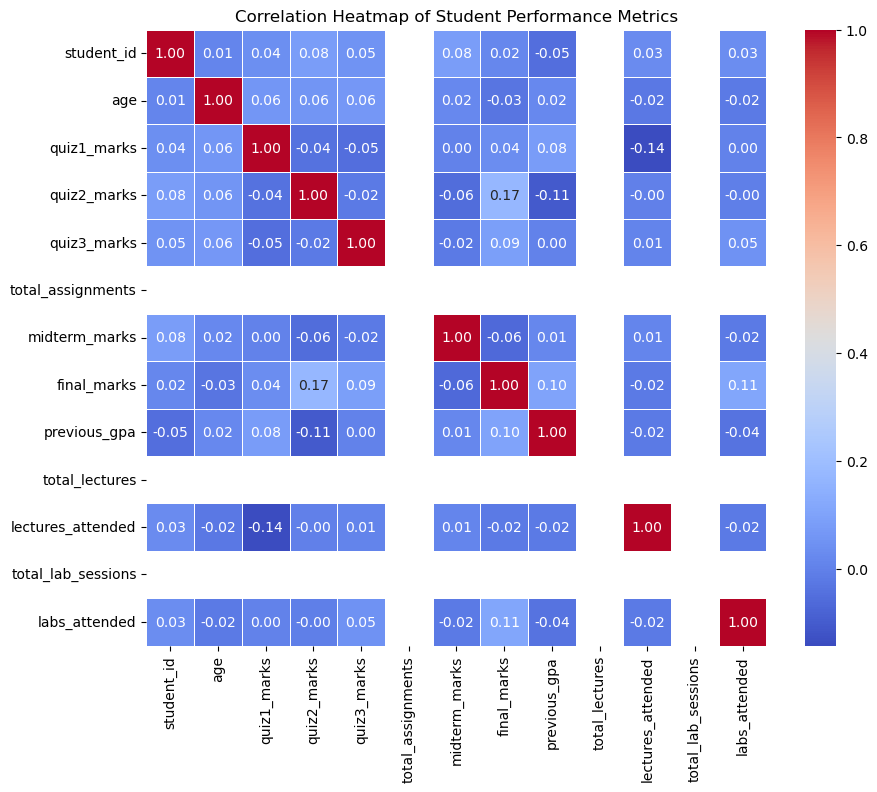

In [36]:
# Visualization 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Student Performance Metrics')
plt.show()



Tidak ada yang memiliki katian cukup kuat, yang terbaik hanya lectures_attended disandingkan dengan quiz1_marks

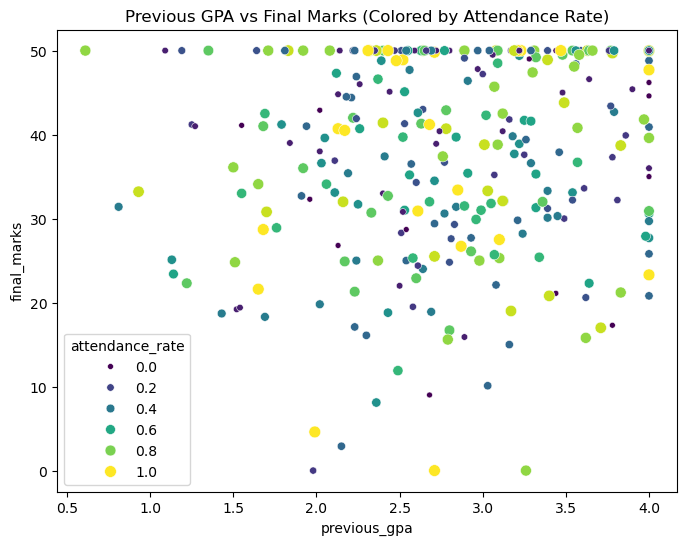

In [ ]:
if 'total_lectures' in df.columns and 'lectures_attended' in df.columns:
    df['attendance_rate'] = df['lectures_attended'] / df['total_lectures']
else:
    df['attendance_rate'] = 0

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='previous_gpa', y='final_marks', hue='attendance_rate', palette='viridis', size='attendance_rate')
plt.title('Previous GPA vs Final Marks (Colored by Attendance Rate)')
plt.show()

Attandance rate tidak terlalu berpengaruh terhadap Final Marks, jadi dosen tidak bisa memperkirakan nilai mahasiswanya hanya dengan attendance rate

# Data Transformation & PCA

In [38]:
scaler = StandardScaler()

df_transformed = df_encoded.copy()

# Apply StandardScaler to the identified numerical columns
df_transformed = scaler.fit_transform(df_transformed)

# Convert the numpy array back to a DataFrame with original column names for display
df_transformed = pd.DataFrame(df_transformed, columns=df_encoded.columns)

# Display the head of the transformed DataFrame to verify
print("DataFrame after standardizing numerical columns:")
df_transformed.head()

DataFrame after standardizing numerical columns:


,student_id,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,-1.726287,-1.139540,1.033908,0.463198,-0.069135,0.713452,0.0,1.214638,-0.074297,-0.322683,0.0,-0.541191,0.0,-1.065997
1,-1.714740,-0.245783,1.033908,1.706127,0.843441,-0.505808,0.0,0.657631,-0.371484,-0.555091,0.0,-1.347601,0.0,0.954850
2,-1.703193,-1.139540,-0.967204,0.152466,-1.935767,-1.909804,0.0,-0.674341,-1.067750,0.251502,0.0,-1.616404,0.0,-1.571208
3,-1.691646,-0.245783,1.033908,-1.276902,-1.396518,1.637133,0.0,-0.274750,0.307801,-1.539408,0.0,0.802826,0.0,-1.571208
4,-1.680099,-0.245783,-0.967204,-0.841877,0.179750,-1.281700,0.0,0.463890,-0.541305,-0.377367,0.0,0.265219,0.0,0.449638


In [39]:
pca = PCA(n_components=13) #why 13 bcs that is total column we have

pca.fit_transform(df_transformed)

array([[-1.18862644e+00,  3.50730638e-01, -6.70730253e-02, ...,
        -5.19663796e-01, -9.10319856e-18,  0.00000000e+00],
       [-6.50521287e-01,  1.28189903e+00,  1.48198952e+00, ...,
        -1.16941716e+00, -5.57479340e-18,  0.00000000e+00],
       [-2.49539857e+00,  1.55284834e+00, -1.73327272e+00, ...,
         7.50181547e-01,  1.10104938e-16,  0.00000000e+00],
       ...,
       [ 1.76486233e+00, -1.82590955e+00,  5.54344210e-01, ...,
         3.34527851e-01, -4.31319914e-17,  0.00000000e+00],
       [ 4.85016785e-01,  2.04638988e-01,  1.48653970e+00, ...,
        -6.73976661e-01,  6.50262608e-17,  0.00000000e+00],
       [ 6.49704620e-01, -2.85845880e-01,  4.08978623e-01, ...,
         8.90517952e-01, -1.38834516e-16,  0.00000000e+00]])

In [40]:
prop_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

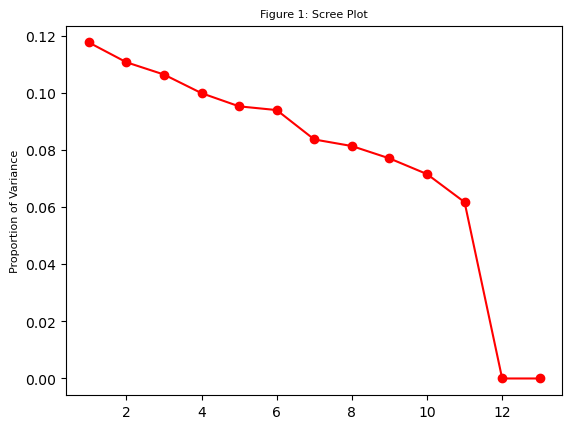

In [41]:
PC_numbers = np.arange(pca.n_components_) + 1

plt.plot(PC_numbers,
         prop_var,
         'ro-')
plt.title('Figure 1: Scree Plot', fontsize=8)
plt.ylabel('Proportion of Variance', fontsize=8)
plt.show()

In [42]:
pca_full = PCA().fit(df_transformed)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("\nExplained variance per PC (percent) & cumulative:")
for i, (e, c) in enumerate(zip(explained*100, cum_explained*100), start=1):
    print(f"PC{i:02d}: {e:.2f}%  |  Cumulative: {c:.2f}%")


Explained variance per PC (percent) & cumulative:
PC01: 11.77%  |  Cumulative: 11.77%
PC02: 11.08%  |  Cumulative: 22.85%
PC03: 10.65%  |  Cumulative: 33.50%
PC04: 10.00%  |  Cumulative: 43.49%
PC05: 9.53%  |  Cumulative: 53.03%
PC06: 9.40%  |  Cumulative: 62.43%
PC07: 8.37%  |  Cumulative: 70.81%
PC08: 8.14%  |  Cumulative: 78.95%
PC09: 7.71%  |  Cumulative: 86.66%
PC10: 7.16%  |  Cumulative: 93.82%
PC11: 6.18%  |  Cumulative: 100.00%
PC12: 0.00%  |  Cumulative: 100.00%
PC13: 0.00%  |  Cumulative: 100.00%
PC14: 0.00%  |  Cumulative: 100.00%


Based on the result, the 8 principal components account for 11.77 + 11.00% + 10.65% + 10.00% + 9.53% + 9.40% + 8.37% + 8.14% = 78.95% of the variance in the data. It is enough because our target is 70-80%

In [43]:
pca = PCA(n_components=8)
PC = pca.fit_transform(df_transformed)

In [44]:
df_pca = pd.DataFrame(data = PC, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])

df_pca.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.188626,0.350731,-0.067073,-0.575436,0.214438,0.044512,-0.657689,-1.684166
1,-0.650521,1.281899,1.481990,-1.316234,-0.000846,-0.693757,1.195048,-0.697328
2,-2.495399,1.552848,-1.733273,-1.706082,-0.961751,-0.527852,0.022905,-0.966573
3,-1.098799,-1.469868,-0.787954,-0.967780,1.259749,1.824789,-0.972216,-0.963283
4,-0.526460,-0.572026,-1.298968,-0.772276,-0.644422,-0.377810,1.814807,-0.485006


In [ ]:
def biplot(score,coef,labels=None, colors=None):

    xs = score[:,0]
    ys = score[:,1]
    n = coef.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    if colors is not None:
        unique_clusters = np.unique(colors)
        for cluster_label in unique_clusters:
            # Filter points belonging to the current cluster
            cluster_mask = (colors == cluster_label)
            plt.scatter(xs[cluster_mask] * scalex,
                        ys[cluster_mask] * scaley,
                        s=5,
                        label=f'Cluster {int(cluster_label)}')
        plt.legend()
    else:
        plt.scatter(xs * scalex,ys * scaley,
                    s=5,
                    color='orange') # Changed 'color' to 'c' and used 'colors' parameter

    for i in range(n):
        plt.arrow(0, 0, coef[i,0],
                  coef[i,1],color = 'purple',
                  alpha = 0.5)
        plt.text(coef[i,0]* 1.2, # Adjusted position
                 coef[i,1] * 1.2, # Adjusted position
                 labels[i],
                 color = 'darkblue',
                 ha = 'center',
                 va = 'center')

    plt.axhline(0, color='black', linestyle='dotted', linewidth=1)
    plt.axvline(0, color='black', linestyle='dotted', linewidth=1)

    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))


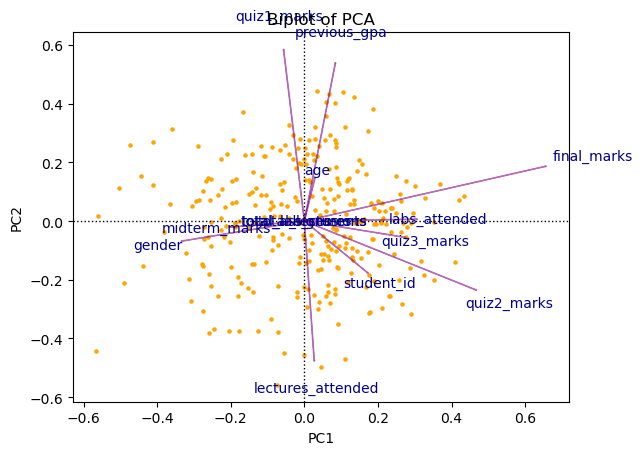

In [46]:
plt.title('Biplot of PCA')

biplot(PC,
       np.transpose(pca.components_),
       list(df_transformed.columns))

PC1 (Horizontal Axis):
final_marks, midterm_marks. quiz2_marks, quiz3_marks, gender.

For PC2 (Vertical Axis):
lectures_attended , quiz1_marks, previous_gpa.

# Clustering (KMeans & Agglomerative)

d:\Learning Apps\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Learning Apps\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Learning Apps\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Learning Apps\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

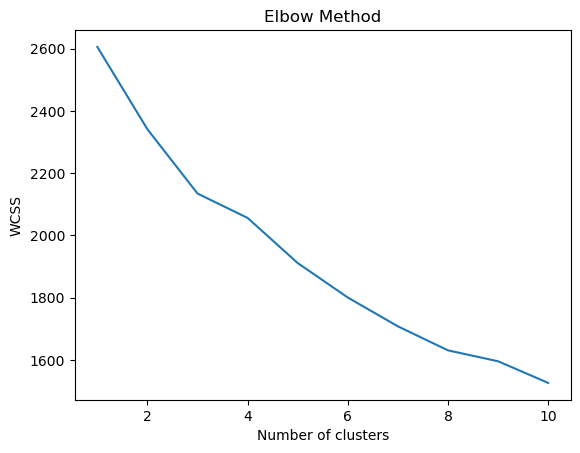

In [47]:
wcss = []
for i in range(1, 11):   #clusters 1-10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [48]:
# Create a DataFrame to display the WCSS values for each number of clusters
wcss_table = pd.DataFrame({
    "Number of Clusters": range(1, 11),
    "WCSS": wcss
})

# Display the table
print(wcss_table)

   Number of Clusters         WCSS
0                   1  2605.355712
1                   2  2340.787923
2                   3  2134.236501
3                   4  2055.916538
4                   5  1910.868614
5                   6  1800.149878
6                   7  1707.519558
7                   8  1630.421386
8                   9  1595.346716
9                  10  1525.831624


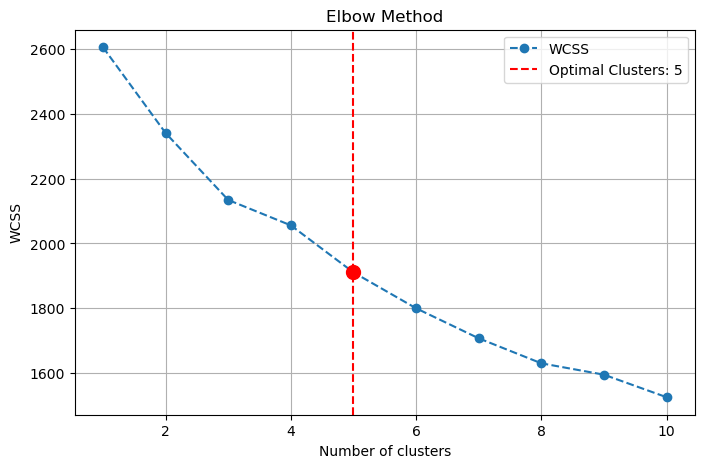

The optimal number of clusters is: 5


In [49]:
from kneed import KneeLocator  # Library to detect the "knee" point

# Example WCSS values and cluster numbers
clusters = range(1, 11)

# Automatically find the elbow point using the KneeLocator
knee_locator = KneeLocator(clusters, wcss, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(clusters, wcss, marker='o', linestyle='--', label="WCSS")
plt.axvline(optimal_clusters, linestyle='--', color='red', label=f'Optimal Clusters: {optimal_clusters}')
plt.scatter(optimal_clusters, wcss[optimal_clusters-1], c='red', s=100, zorder=5)  # Highlight elbow point
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()

# Print the optimal number of clusters
print(f"The optimal number of clusters is: {optimal_clusters}")


In [50]:
# Fit K-Means to the data with optimal cluster
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++',random_state=42)
kmeans_cluster = kmeans.fit_predict(df_pca)

# Add the cluster labels to the DataFrame
df['KMeans'] = kmeans_cluster
df_transformed['KMeans'] = kmeans_cluster

d:\Learning Apps\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [51]:
# Evaluation
ss = silhouette_score(df_pca, kmeans_cluster)
print(ss)

0.09896261504218072


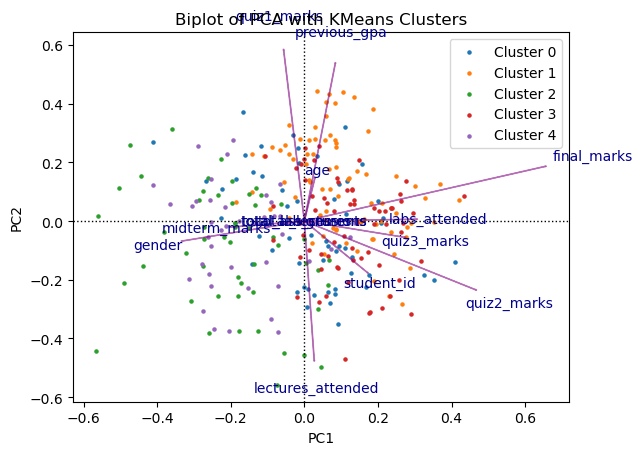

In [52]:
plt.title('Biplot of PCA with KMeans Clusters')
biplot(PC,
       np.transpose(pca.components_),
       list(df_transformed.columns),
       colors=df_transformed['KMeans'])
plt.show()

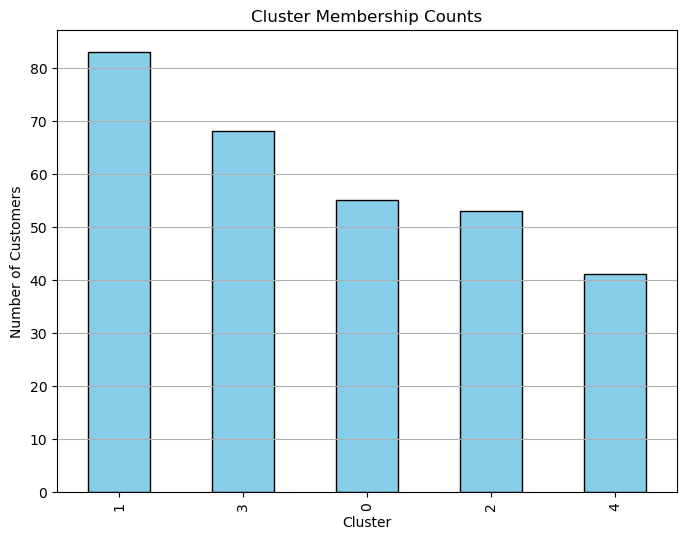

In [53]:
cluster_counts = df['KMeans'].value_counts()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cluster Membership Counts')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.show()

In [66]:
cluster_summary = df.groupby('KMeans').agg({
    'gender': [('mode', lambda x: x.mode()[0]), 'count'],
    'age': ['mean', 'std', 'min', 'max'],
    'quiz1_marks': ['mean', 'std', 'min', 'max'],
    'quiz2_marks': ['mean', 'std', 'min', 'max'],
    'quiz3_marks': ['mean', 'std', 'min', 'max'],
    'midterm_marks': ['mean', 'std', 'min', 'max'],
    'final_marks': ['mean', 'std', 'min', 'max'],
    'previous_gpa': ['mean', 'std', 'min', 'max'],
    'lectures_attended': ['mean', 'std', 'min', 'max'],
})

# Rename the index to 'cluster' for clarity
cluster_summary = cluster_summary.rename_axis('Cluster')

# Display the cluster summary
pd.set_option('display.max_columns', None)


# Tampilkan dataframe kamu
display(cluster_summary)

gender              age                   quiz1_marks                 \
           mode count       mean       std min max        mean       std  min   
Cluster                                                                         
0        Female    55  20.381818  1.929219  18  25    6.652727  1.535971  2.8   
1        Female    83  22.433735  2.090587  18  25    7.681928  1.587769  3.8   
2          Male    53  22.113208  2.118239  18  25    6.447170  1.681643  2.8   
3          Male    68  21.500000  2.215953  18  25    7.448529  1.265205  4.0   
4          Male    41  20.682927  2.195894  18  24    7.919512  1.565442  3.9   

              quiz2_marks                      quiz3_marks                 \
          max        mean       std  min   max        mean       std  min   
Cluster                                                                     
0        10.0    6.060000  2.213143  1.0  10.0    3.334545  2.217959  0.0   
1        10.0    5.324096  2.189030  1.3  10.0    6.730120  2.317470  0.8   
2        10.0    4.784906  2.342779  0.0   9.8    6.190566  2.514899  0.7   
3        10.0    7.555882  2.044022  2.9  10.0    6.164706  2.447952  0.0   
4        10.0    5.302439  2.372603  1.6  10.0    3.692683  2.172371  0.0   

              midterm_marks                       final_marks             \
          max          mean       std   min   max        mean        std   
Cluster                                                                    
0         8.3     16.816364  8.520602   0.0  30.0   39.609091  10.208843   
1        10.0     22.766265  7.080242   0.0  30.0   43.501205   7.662778   
2        10.0     20.156604  7.941675   2.0  30.0   23.981132  10.475871   
3        10.0     15.417647  7.699059   0.0  30.0   43.179412   6.993933   
4         7.5     25.841463  5.380101  13.1  30.0   29.663415  10.672974   

                    previous_gpa                      lectures_attended  \
          min   max         mean       std   min  max              mean   
Cluster                                                                   
0        11.9  50.0     2.973091  0.700156  0.93  4.0          7.400000   
1        22.1  50.0     3.309518  0.506456  2.18  4.0          6.156627   
2         0.0  50.0     2.523208  0.685413  0.81  4.0          6.415094   
3        26.8  50.0     2.405588  0.675738  0.61  3.9          4.000000   
4         0.0  50.0     2.592439  0.678203  1.14  4.0          6.682927   

                           
              std min max  
Cluster                    
0        3.734722   0  12  
1        3.839722   0  12  
2        3.707757   0  12  
3        3.218417   0  11  
4        3.044988   1  12

Cluster 0: Rajin tapi Nilainya masih kurang
Dominasi: Perempuan (Female), Usia rata-rata termuda (20.3 tahun).

Karakteristik:

Paling Rajin: Memiliki tingkat Kehadiran Tertinggi (7.4 kali).
Performa: Sayangnya, kerajinan mereka belum terbayar lunas di ujian. Nilai Midterm/UTS mereka rendah (16.8) dan nilai Quiz 3 sangat anjlok (3.33).

Rekomendasi : Perbanyak Belajar di luar kelas, Coba lebih fokus lagi saat di kelas, dan jika tidak mengerti mungkin bisa tanya ke Dosennya


Cluster 1: Mahasiswa Berprestasi
Dominasi: Perempuan (Female), Usia rata-rata tertua (22.4 tahun).

Karakteristik:

Ini adalah kelompok dengan performa terbaik secara keseluruhan.
Nilai Tertinggi: Mereka memiliki rata-rata IPK (Previous GPA) tertinggi (3.31) dan nilai Final/UAS tertinggi (43.5).
Konsisten: Nilai Quiz 1, 2, dan 3 mereka stabil di angka tinggi.
Jumlah: Merupakan populasi terbesar (83 mahasiswa).

Rekomendasi : Pertahankan, tapi tetap berusaha berkembang setiap harinya

Cluster 2: "The At-Risk Group" (Kelompok Berisiko)
Dominasi: Laki-laki (Male).

Karakteristik:

Perlu Perhatian Khusus: Kelompok ini paling mengkhawatirkan.
Nilai Terendah: Mereka memiliki nilai Final/UAS paling rendah (23.9)—jauh di bawah rata-rata kelas.
IPK mereka juga rendah (2.52). Meskipun Quiz 3 mereka lumayan, secara umum performa ujian besar (UAS) mereka gagal.

Rekomendasi : Mencari Tahu apakah ada masalah dalam diri yang menyebabkan kenapa kita gagal dalam pelajaran, atau mungkin bisa pindah jurusan saja jika memang dirasa sudah tidak cocok.

Cluster 3: Pintar tapi Malas Masuk
Dominasi: Laki-laki (Male).

Karakteristik:

Ini kelompok yang unik. Mereka memiliki Kehadiran Terendah (Rata-rata hanya 4 kali) dan IPK Terendah (2.40).
Kejutan: Meskipun jarang masuk dan IPK rendah, nilai Final/UAS mereka sangat tinggi (43.1), hampir menyamai Cluster 1. Bahkan nilai Quiz 2 mereka adalah yang tertinggi (7.55).

Mahasiswa ini cerdas secara akademis dan bisa mengerjakan ujian dengan baik, tetapi memiliki kedisiplinan (kehadiran) yang sangat buruk.

Rekomendasi : Berusaha untuk lebih sering masuk kelas, supaya bisa lulus kuliah dengan nilai yang memuaskan


Cluster 4: Mulai Bagus, Akhir Menurun
Dominasi: Laki-laki (Male).

Karakteristik:

Awal yang Kuat: Mereka juara di awal semester. Memiliki nilai Quiz 1 Tertinggi (7.9) dan Midterm/UTS Tertinggi (25.8).
Penurunan Drastis: Performa mereka anjlok di akhir semester. Nilai Quiz 3 rendah (3.6) dan nilai Final/UAS rendah (29.6).

Rekomendasi : Lebih santai lagi, jangan terlalu memaksakan diri di awal, coba perubahan kecil saja tapi bisa di pertahankan

